# Bank Customer Churn Prediction using ANN



In [1]:
# Importing all the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.16.2


## 1. Loading the Dataset

The dataset is from Kaggle — Bank Customers dataset. Upload it or mount from Google Drive.

In [6]:
# Load the dataset
from pathlib import Path

csv_path = Path('Churn Modeling.xls')
if not csv_path.exists():
    csv_path = Path('Churn Modeling.csv')

if not csv_path.exists():
    raise FileNotFoundError('Dataset not found. Place Churn Modeling.csv or Churn Modeling.xls in the notebook directory.')

df = pd.read_csv(csv_path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Basic info about the dataset
print('Shape:', df.shape)
print('\nColumn Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Shape: (10000, 14)

Column Types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 2. Exploratory Data Analysis (EDA)

Let's explore the data and see what patterns we can find.

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


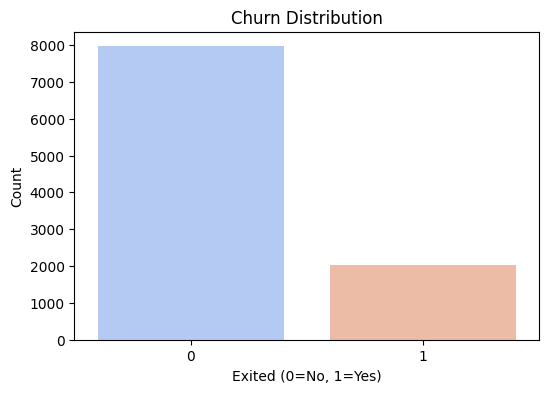

In [9]:
# Check the target variable distribution
print('Churn Distribution:')
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean()*100:.2f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette='coolwarm')
plt.title('Churn Distribution')
plt.xlabel('Exited (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()


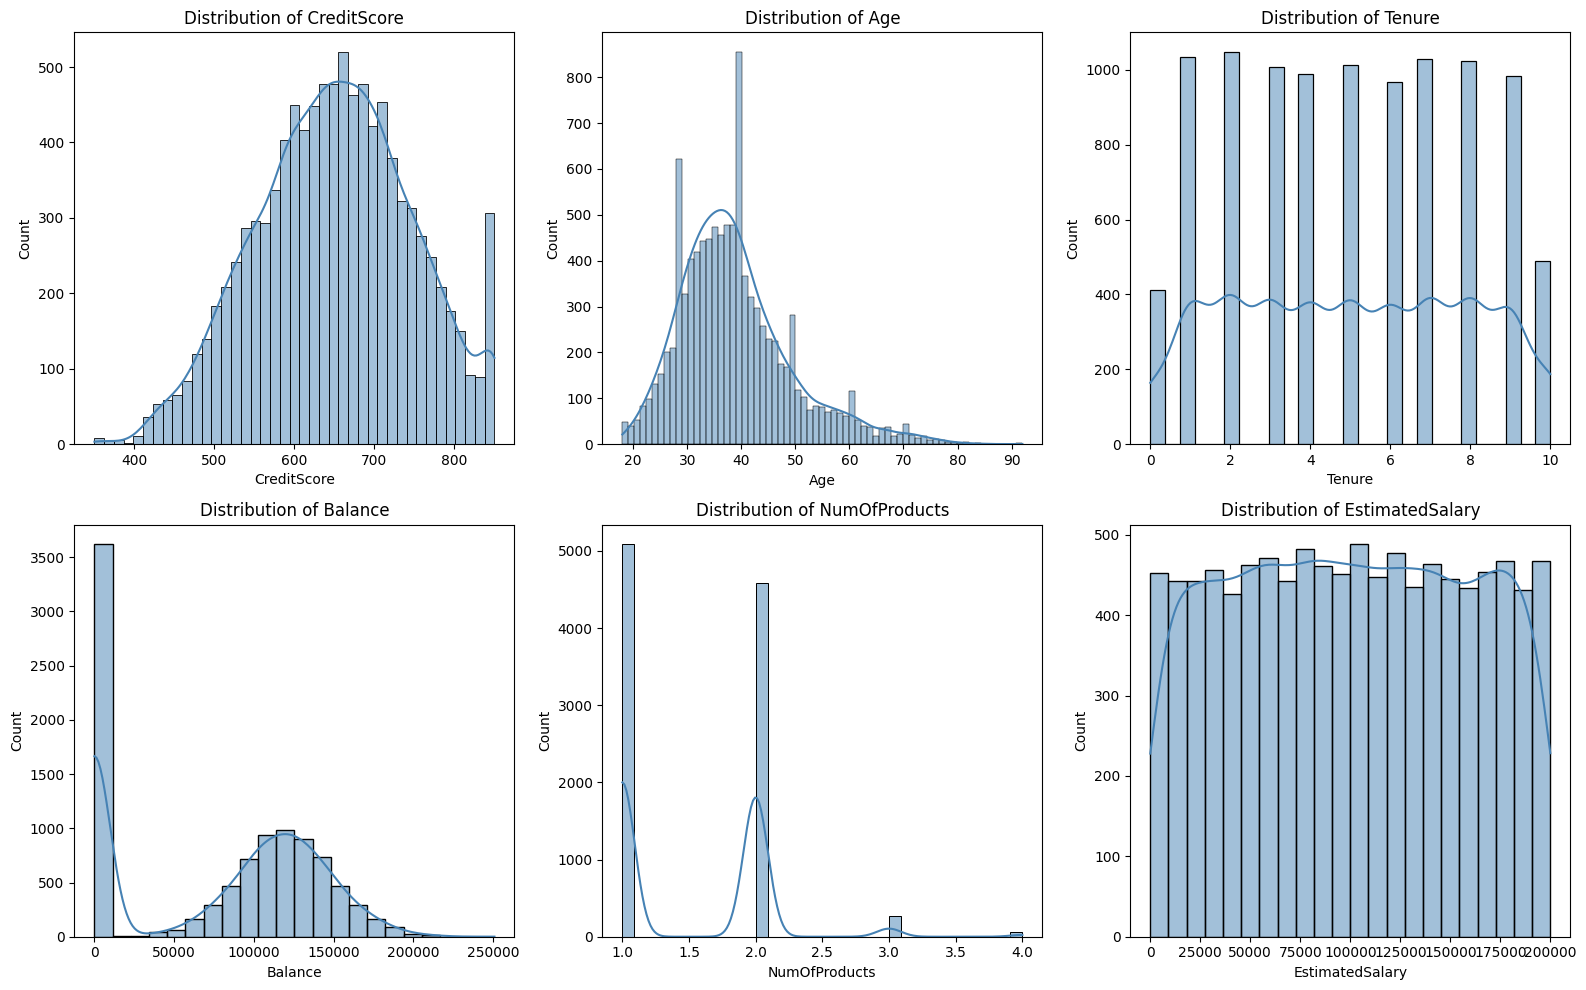

In [10]:
# Distribution of numerical features
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

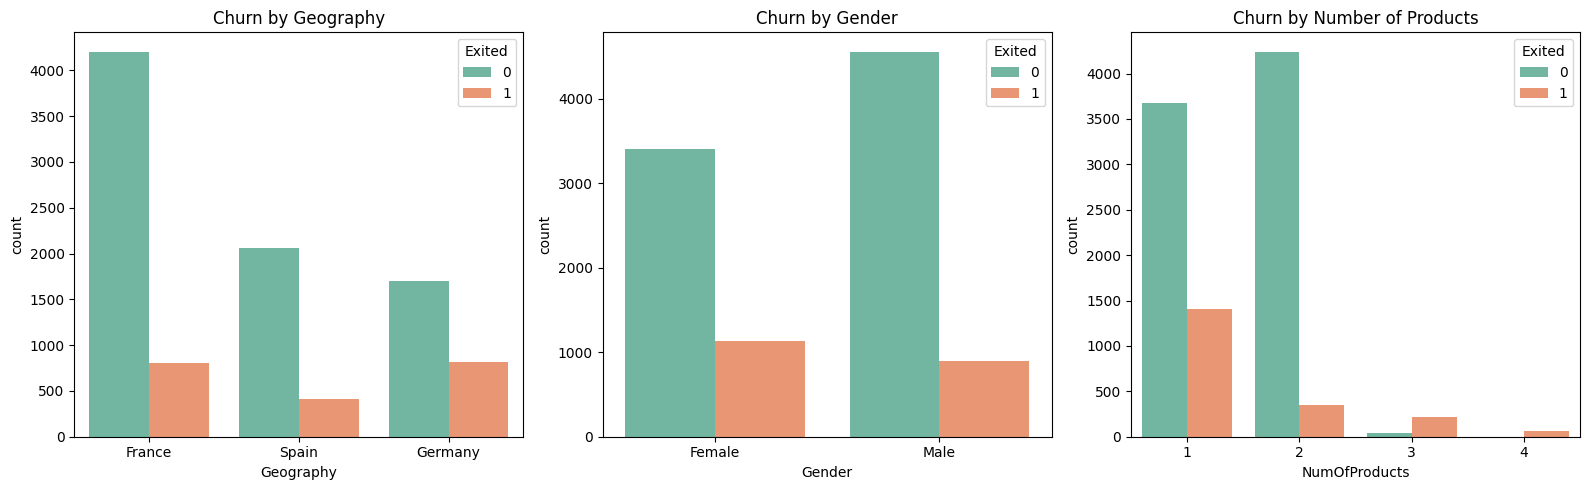

In [11]:
# Churn vs categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(x='Geography', hue='Exited', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Geography')

sns.countplot(x='Gender', hue='Exited', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Churn by Gender')

sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='Set2', ax=axes[2])
axes[2].set_title('Churn by Number of Products')

plt.tight_layout()
plt.show()

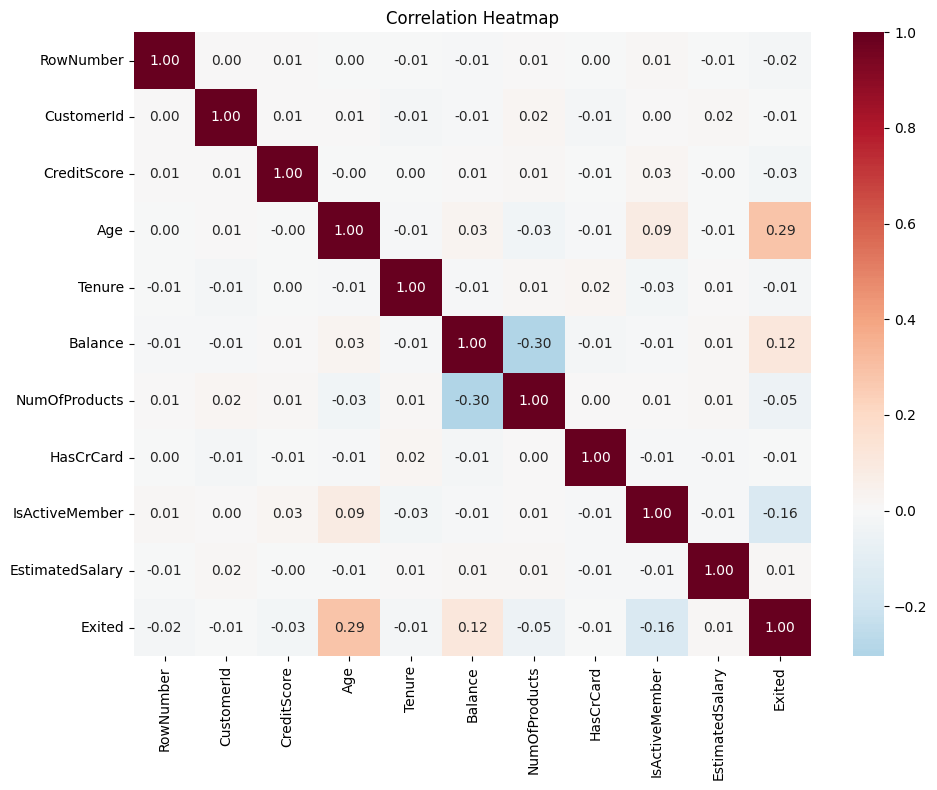

In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


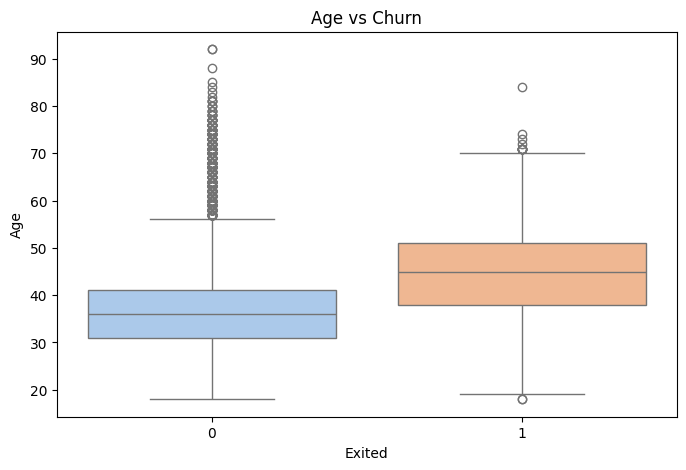

In [13]:
# Age distribution by churn status
plt.figure(figsize=(8, 5))
sns.boxplot(x='Exited', y='Age', data=df, palette='pastel')
plt.title('Age vs Churn')
plt.show()


## 3. Checking Distributions / Skewness

Let's check if any columns are heavily skewed and need transformation.

In [14]:
# Check skewness
for col in numerical_cols:
    skew_val = df[col].skew()
    print(f'{col}: Skewness = {skew_val:.4f}')
    if abs(skew_val) > 1:
        print(f'  --> {col} is highly skewed, might need transformation')

CreditScore: Skewness = -0.0716
Age: Skewness = 1.0113
  --> Age is highly skewed, might need transformation
Tenure: Skewness = 0.0110
Balance: Skewness = -0.1411
NumOfProducts: Skewness = 0.7456
EstimatedSalary: Skewness = 0.0021


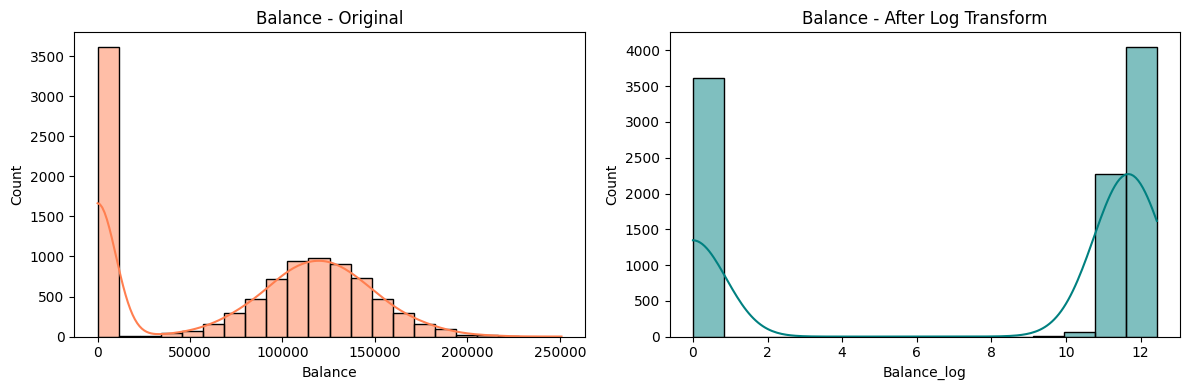

In [15]:
# Apply log transformation to Balance (it has a lot of zeros though)
# Let's use log1p to handle zeros
df['Balance_log'] = np.log1p(df['Balance'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Balance'], kde=True, ax=axes[0], color='coral')
axes[0].set_title('Balance - Original')
sns.histplot(df['Balance_log'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Balance - After Log Transform')
plt.tight_layout()
plt.show()

## 4. Outlier Treatment & Feature Scaling

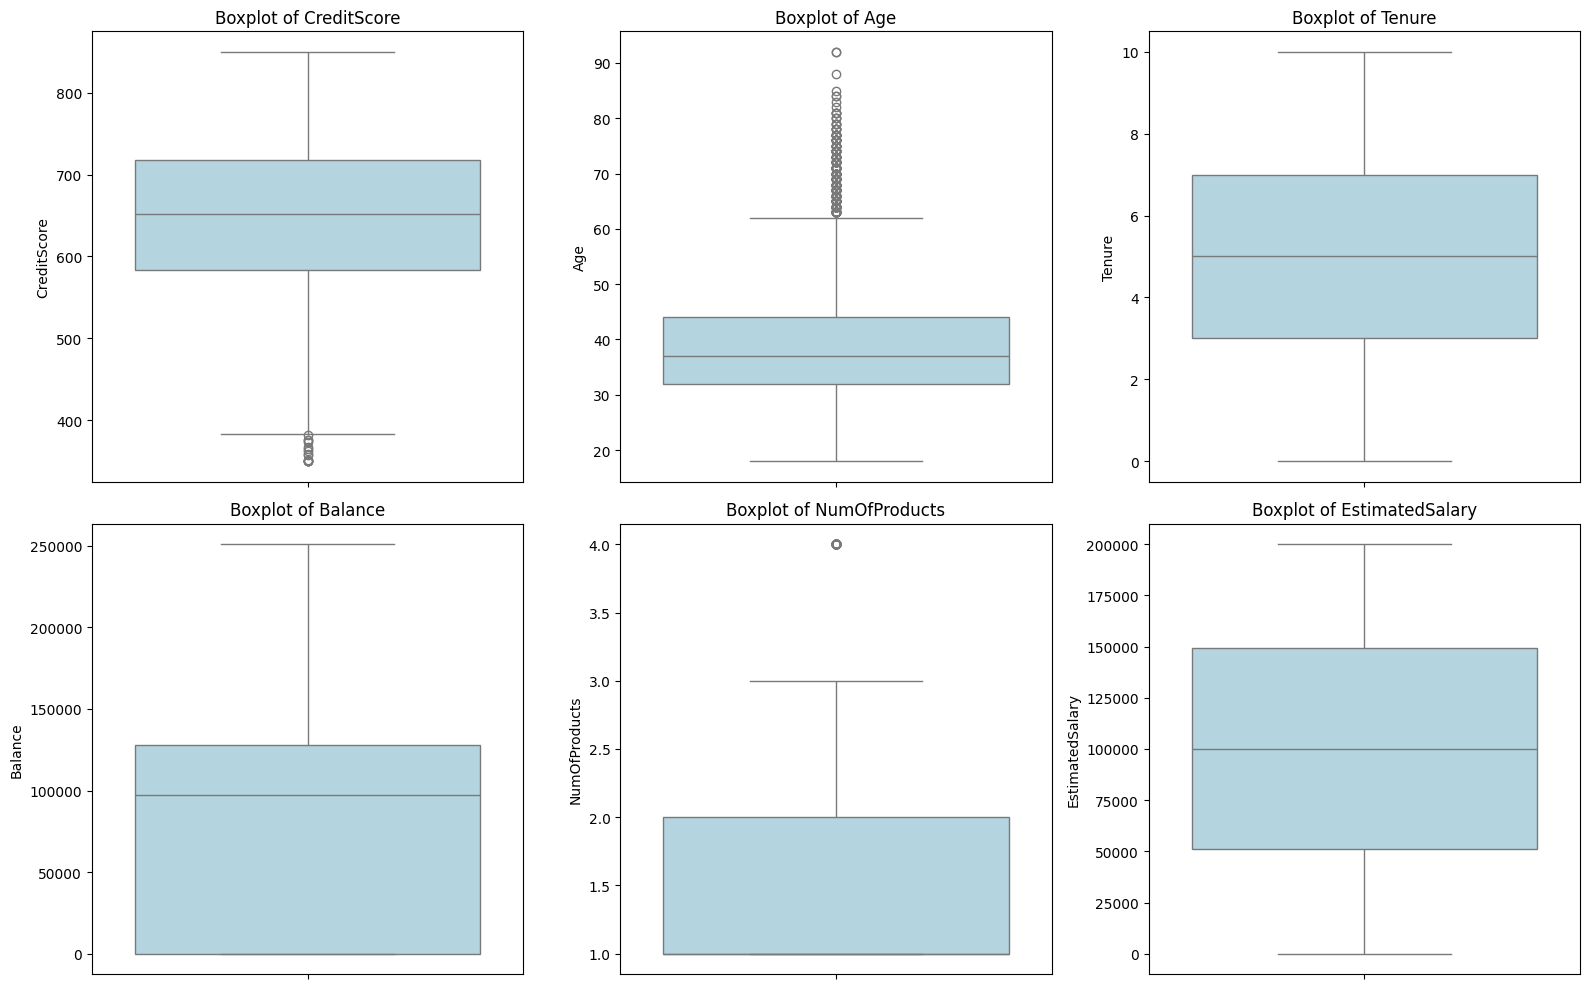

In [16]:
# Check for outliers using boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [17]:
# Let's cap the outliers using IQR method for CreditScore and Age
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

df = cap_outliers(df, 'CreditScore')
df = cap_outliers(df, 'Age')
print('Outliers capped for CreditScore and Age')

Outliers capped for CreditScore and Age


In [18]:
# Prepare features
# Drop unnecessary columns
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Balance_log'], axis=1)

# Encode categorical variables
le_geo = LabelEncoder()
le_gender = LabelEncoder()
df_model['Geography'] = le_geo.fit_transform(df_model['Geography'])
df_model['Gender'] = le_gender.fit_transform(df_model['Gender'])

print('Encoded columns')
df_model.head()

Encoded columns


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [19]:
# Split features and target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

print('Features shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Features shape: (10000, 10)
Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (8000, 10)
Test set: (2000, 10)


In [21]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Feature scaling done!')

Feature scaling done!


## 5. Building ANN with Multiple Hidden Layers

Let's build our first deep learning model with multiple hidden layers, dropout, and batch normalization.

In [22]:
# Model 1: Basic ANN with multiple hidden layers
model_1 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

## 6. Training with Early Stopping & ModelCheckpoint

In [23]:
# Set up callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model_1.keras',
    monitor='val_loss',
    save_best_only=False,  # save after every epoch as required
    verbose=1
)

print('Callbacks ready!')

Callbacks ready!


In [24]:
# Train the model
history_1 = model_1.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
193/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7704 - loss: 0.4992
Epoch 1: saving model to best_model_1.keras

Epoch 1: finished saving model to best_model_1.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7725 - loss: 0.4978 - val_accuracy: 0.8175 - val_loss: 0.4330
Epoch 2/100
192/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8153 - loss: 0.4311
Epoch 2: saving model to best_model_1.keras

Epoch 2: finished saving model to best_model_1.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8158 - loss: 0.4298 - val_accuracy: 0.8562 - val_loss: 0.3820
Epoch 3/100
171/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8194 - loss: 0.4130
Epoch 3: saving model to best_model_1.keras

Epoch 3: finished saving model to best_model_1.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8211 - loss: 0.4116 - val_accuracy: 0.8606 - val_loss: 0.3623
Epoch 4/100
177/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8174 - loss: 0.4028
Epoch 4

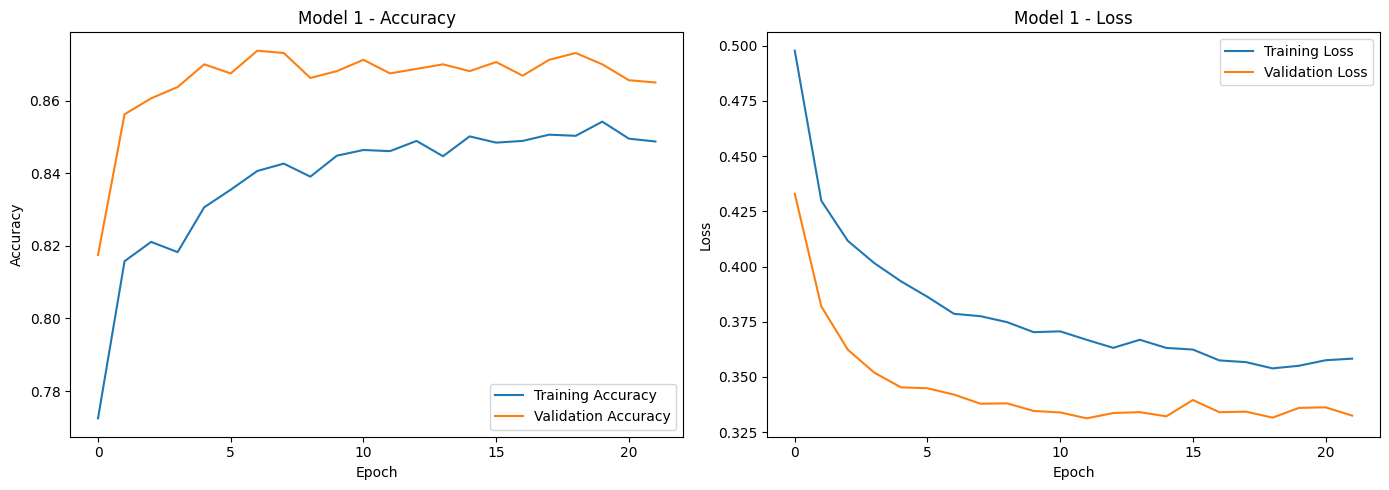

In [25]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_1.history['accuracy'], label='Training Accuracy')
axes[0].plot(history_1.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model 1 - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_1.history['loss'], label='Training Loss')
axes[1].plot(history_1.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model 1 - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 1 Test Accuracy: 0.8605

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



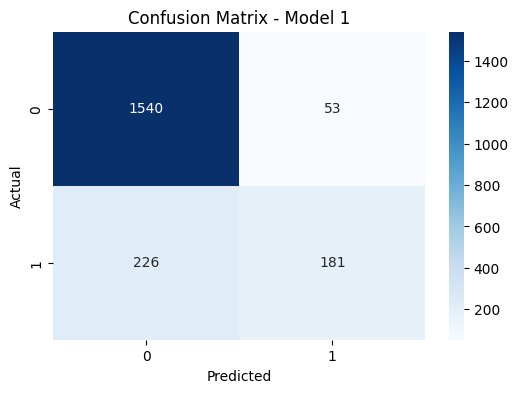

In [26]:
# Evaluate Model 1
y_pred_1 = (model_1.predict(X_test_scaled) > 0.5).astype(int).flatten()
acc_1 = accuracy_score(y_test, y_pred_1)
print(f'Model 1 Test Accuracy: {acc_1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_1))

# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_1), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Model 1')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Model 2: Different Architecture

Let's try a different architecture with more layers and see if it performs better.

In [27]:
# Model 2: Deeper network with different config
model_2 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

early_stop_2 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
checkpoint_2 = ModelCheckpoint('best_model_2.keras', monitor='val_loss', save_best_only=False, verbose=0)

history_2 = model_2.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_2, checkpoint_2],
    verbose=1
)

# Evaluate
y_pred_2 = (model_2.predict(X_test_scaled) > 0.5).astype(int).flatten()
acc_2 = accuracy_score(y_test, y_pred_2)
print(f'\nModel 2 Test Accuracy: {acc_2:.4f}')

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7258 - loss: 0.5600 - val_accuracy: 0.8000 - val_loss: 0.4874
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8053 - loss: 0.4568 - val_accuracy: 0.8025 - val_loss: 0.4219
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8173 - loss: 0.4286 - val_accuracy: 0.8231 - val_loss: 0.3908
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8238 - loss: 0.4133 - val_accuracy: 0.8562 - val_loss: 0.3658
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8275 - loss: 0.4011 - val_accuracy: 0.8656 - val_loss: 0.3535
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8331 - loss: 0.4010 - val_accuracy: 0.8719 - val_loss: 0.3497
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8383 - loss: 0.3904 - val_accuracy: 0.8694 - val_loss: 0.3478
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8397 - loss: 0.3862 - val_accu

## 8. Hyperparameter Tuning with KerasTuner

Now let's use KerasTuner to automatically find the best hyperparameters. We'll tune the number of hidden layers, units, activation functions, optimizer, dropout rate, etc.

In [28]:
import keras_tuner as kt

# Define the hypermodel
def build_model(hp):
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        units=hp.Int('units_first', min_value=32, max_value=256, step=32),
        activation=hp.Choice('activation', ['relu', 'tanh']),
        input_shape=(X_train_scaled.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_first', min_value=0.1, max_value=0.5, step=0.1)))

    # Variable number of hidden layers
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ))
        model.add(Dropout(hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Choose optimizer
    optimizer_choice = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    if optimizer_choice == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=lr)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print('Hypermodel function defined!')

Hypermodel function defined!


In [29]:
# Create the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='churn_prediction'
)

tuner.search_space_summary()

Search space summary
Default search space size: 8
units_first (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_first (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd', 'rmsprop'], 'ordered': False}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampli

In [30]:
# Run the search
tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

Trial 10 Complete [00h 00m 12s]
val_accuracy: 0.8687499761581421

Best val_accuracy So Far: 0.875
Total elapsed time: 00h 04m 04s


In [31]:
# Get the best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print('Best Hyperparameters:')
print(f"  Units (first layer): {best_hp.get('units_first')}")
print(f"  Activation: {best_hp.get('activation')}")
print(f"  Number of hidden layers: {best_hp.get('num_layers')}")
print(f"  Optimizer: {best_hp.get('optimizer')}")
print(f"  Learning Rate: {best_hp.get('learning_rate'):.6f}")
print(f"  Dropout (first): {best_hp.get('dropout_first')}")

Best Hyperparameters:
  Units (first layer): 96
  Activation: relu
  Number of hidden layers: 2
  Optimizer: rmsprop
  Learning Rate: 0.000397
  Dropout (first): 0.5


In [32]:
# Build the best model and train it
best_model = tuner.hypermodel.build(best_hp)

early_stop_best = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
checkpoint_best = ModelCheckpoint('best_tuned_model.keras', monitor='val_loss', save_best_only=False, verbose=0)

history_best = best_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_best, checkpoint_best],
    verbose=1
)

best_model.summary()

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7542 - loss: 0.5489 - val_accuracy: 0.8219 - val_loss: 0.4749
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7936 - loss: 0.4775 - val_accuracy: 0.8375 - val_loss: 0.4195
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8014 - loss: 0.4584 - val_accuracy: 0.8544 - val_loss: 0.4077
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8092 - loss: 0.4380 - val_accuracy: 0.8569 - val_loss: 0.3851
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8131 - loss: 0.4336 - val_accuracy: 0.8600 - val_loss: 0.3722
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8164 - loss: 0.4250 - val_accuracy: 0.8581 - val_loss: 0.3655
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.4235 - val_accuracy: 0.8587 - val_loss: 0.3643
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8245 - loss: 0.4157 - val_accu

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 96)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 192)            │        18,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,356 (204.52 KB)

 Trainable params: 26,081 (101.88 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 26,083 (101.89 KB)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Best Tuned Model Test Accuracy: 0.8630

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.80      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.84      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000



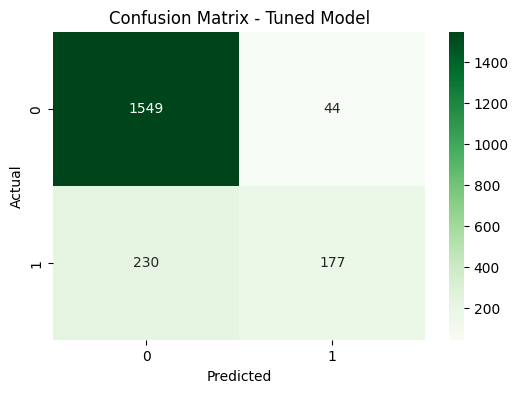

In [33]:
# Evaluate the tuned model
y_pred_best = (best_model.predict(X_test_scaled) > 0.5).astype(int).flatten()
acc_best = accuracy_score(y_test, y_pred_best)
print(f'Best Tuned Model Test Accuracy: {acc_best:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Tuned Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 9. Model Comparison

Let's put all models side by side and see which one performed the best.

In [34]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Model 1 (Basic ANN)', 'Model 2 (Deeper ANN)', 'Model 3 (KerasTuner Best)'],
    'Test Accuracy': [acc_1, acc_2, acc_best],
    'Architecture': [
        '128-64-32-16 (Dropout 0.3/0.2)',
        '256-128-64-32-16 (Dropout 0.4/0.3/0.2)',
        f'Tuned ({best_hp.get("optimizer")}, lr={best_hp.get("learning_rate"):.5f})'
    ]
})
results = results.sort_values('Test Accuracy', ascending=False)
print(results.to_string(index=False))

                    Model  Test Accuracy                           Architecture
Model 3 (KerasTuner Best)         0.8630            Tuned (rmsprop, lr=0.00040)
     Model 2 (Deeper ANN)         0.8615 256-128-64-32-16 (Dropout 0.4/0.3/0.2)
      Model 1 (Basic ANN)         0.8605         128-64-32-16 (Dropout 0.3/0.2)


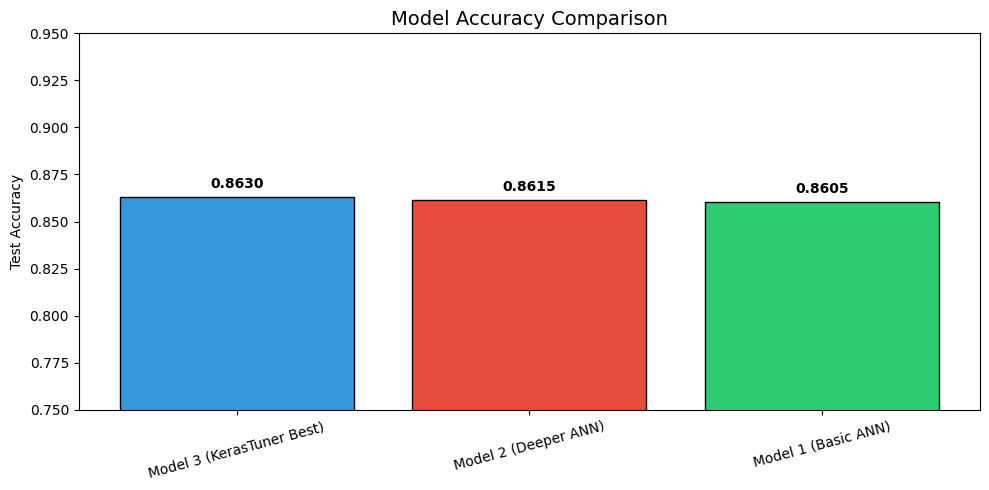

In [35]:
# Visualize comparison
plt.figure(figsize=(10, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = plt.bar(results['Model'], results['Test Accuracy'], color=colors, edgecolor='black')
plt.ylim(0.75, 0.95)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Test Accuracy')
plt.xticks(rotation=15)

# Add value labels on bars
for bar, acc in zip(bars, results['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
# Final Verdict
best_idx = results['Test Accuracy'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_acc = results.loc[best_idx, 'Test Accuracy']

print(f'\n{"="*50}')
print(f'BEST MODEL: {best_model_name}')
print(f'Test Accuracy: {best_acc:.4f}')
print(f'{"="*50}')
print('\nThis model performed the best on the test set and is our final choice for churn prediction.')


BEST MODEL: Model 3 (KerasTuner Best)
Test Accuracy: 0.8630

This model performed the best on the test set and is our final choice for churn prediction.
